<a href="https://colab.research.google.com/github/ArkanUbaidillah/DeepLearning_B_2411537001_ArkanUbaidillahWarman/blob/main/Praktikum2/2411537001_ArkanUbaidillahWarman_TugasProgram2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tugas Individu
### 1 dan 2. Ubah arsitektur, ulangi pelatihan, dan catat akurasi baru
Eksperimen mengubah arsitektur dengan tiga variasi terhadap baseline CNN_1 (2 lapisan konvolusi, kernel 3×3). CNN_2 menambah satu lapisan konvolusi (32 ke 64 filter). CNN_3 memperbesar kernel menjadi 5×5. CNN_4 menggabungkan lapisan tambahan dan kernel 5×5. Semua model memakai optimizer Adam (learning rate 0,001), 5 epoch, batch size 64, dan seed 42.

In [ ]:
# Tugas Individu: fungsi bantu untuk eksperimen arsitektur
def latih_dan_uji(nama, model, epochs=5, lr=0.001):
    torch.manual_seed(42)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    riwayat_loss = []
    mulai = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        riwayat_loss.append(running_loss / len(trainloader))
        print(f'{nama} | Epoch [{epoch+1}/{epochs}], Loss: {riwayat_loss[-1]:.4f}')
    waktu = time.time() - mulai
    akurasi = hitung_akurasi(model, testloader)
    print(f'{nama} | Akurasi Uji: {akurasi:.2f}% | Waktu Training: {waktu:.2f} detik\n')
    return riwayat_loss, akurasi, waktu

#### CNN_2

In [ ]:
# CNN_2: 3 lapisan konvolusi (kernel 3x3)
class CNN_2(nn.Module):
    def __init__(self):
        super(CNN_2, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))   # 28x28 -> 14x14
        x = self.pool(nn.ReLU()(self.conv2(x)))   # 14x14 -> 7x7
        x = self.pool(nn.ReLU()(self.conv3(x)))   # 7x7 -> 3x3
        x = x.view(-1, 64 * 3 * 3)
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)
        return x

torch.manual_seed(42)
model_cnn2 = CNN_2()
loss_cnn2, acc_cnn2, waktu_cnn2 = latih_dan_uji('CNN_2', model_cnn2)

CNN_2 | Epoch [1/5], Loss: 0.2223


CNN_2 | Epoch [2/5], Loss: 0.0546


CNN_2 | Epoch [3/5], Loss: 0.0388


CNN_2 | Epoch [4/5], Loss: 0.0317


CNN_2 | Epoch [5/5], Loss: 0.0248


CNN_2 | Akurasi Uji: 98.78% | Waktu Training: 96.99 detik



#### CNN_3

In [ ]:
# CNN_3: 2 lapisan konvolusi dengan kernel 5x5
class CNN_3(nn.Module):
    def __init__(self):
        super(CNN_3, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, 5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))   # 28x28 -> 14x14
        x = self.pool(nn.ReLU()(self.conv2(x)))   # 14x14 -> 7x7
        x = x.view(-1, 32 * 7 * 7)
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)
        return x

torch.manual_seed(42)
model_cnn3 = CNN_3()
loss_cnn3, acc_cnn3, waktu_cnn3 = latih_dan_uji('CNN_3', model_cnn3)

CNN_3 | Epoch [1/5], Loss: 0.1688


CNN_3 | Epoch [2/5], Loss: 0.0486


CNN_3 | Epoch [3/5], Loss: 0.0334


CNN_3 | Epoch [4/5], Loss: 0.0265


CNN_3 | Epoch [5/5], Loss: 0.0199


CNN_3 | Akurasi Uji: 98.75% | Waktu Training: 97.85 detik



#### CNN_4

In [ ]:
# CNN_4: 3 lapisan konvolusi dengan kernel 5x5
class CNN_4(nn.Module):
    def __init__(self):
        super(CNN_4, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, 5, padding=2)
        self.conv3 = nn.Conv2d(32, 64, 5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))   # 28x28 -> 14x14
        x = self.pool(nn.ReLU()(self.conv2(x)))   # 14x14 -> 7x7
        x = self.pool(nn.ReLU()(self.conv3(x)))   # 7x7 -> 3x3
        x = x.view(-1, 64 * 3 * 3)
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)
        return x

torch.manual_seed(42)
model_cnn4 = CNN_4()
loss_cnn4, acc_cnn4, waktu_cnn4 = latih_dan_uji('CNN_4', model_cnn4)

CNN_4 | Epoch [1/5], Loss: 0.1942


CNN_4 | Epoch [2/5], Loss: 0.0475


CNN_4 | Epoch [3/5], Loss: 0.0330


CNN_4 | Epoch [4/5], Loss: 0.0272


CNN_4 | Epoch [5/5], Loss: 0.0217


CNN_4 | Akurasi Uji: 98.95% | Waktu Training: 125.97 detik



### 3. Hasil dalam bentuk tabel

In [ ]:
# Tabel hasil eksperimen
import pandas as pd

hasil = pd.DataFrame({
    'Eksperimen': ['CNN_1', 'CNN_2', 'CNN_3', 'CNN_4'],
    'Jumlah Layer': ['2 conv', '3 conv', '2 conv', '3 conv'],
    'Ukuran Kernel': ['3x3', '3x3', '5x5', '5x5'],
    'Akurasi (%)': [round(akurasi_test, 2), round(acc_cnn2, 2), round(acc_cnn3, 2), round(acc_cnn4, 2)],
    'Waktu Training (s)': [round(waktu_cnn1, 1), round(waktu_cnn2, 1), round(waktu_cnn3, 1), round(waktu_cnn4, 1)],
    'Jumlah Parameter': [
        sum(p.numel() for p in model.parameters()),
        sum(p.numel() for p in model_cnn2.parameters()),
        sum(p.numel() for p in model_cnn3.parameters()),
        sum(p.numel() for p in model_cnn4.parameters()),
    ],
})
hasil

,Eksperimen,Jumlah Layer,Ukuran Kernel,Akurasi (%),Waktu Training (s),Jumlah Parameter
0,CNN_1,2 conv,3x3,98.70,80.4,206922
1,CNN_2,3 conv,3x3,98.78,97.0,98442
2,CNN_3,2 conv,5x5,98.75,97.8,215370
3,CNN_4,3 conv,5x5,98.95,126.0,139658


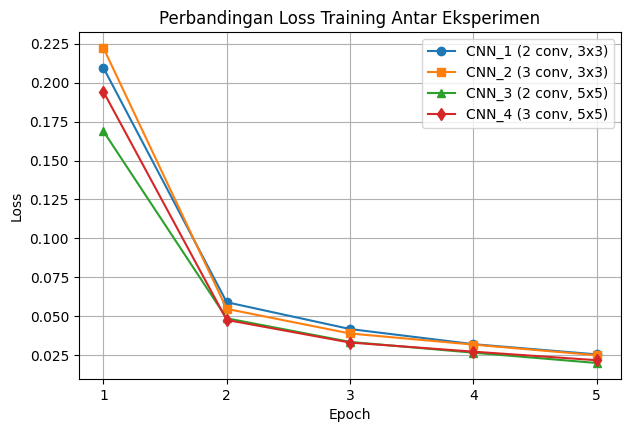

In [ ]:
# Perbandingan grafik loss semua eksperimen
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, 6), train_loss, marker='o', label='CNN_1 (2 conv, 3x3)')
plt.plot(range(1, 6), loss_cnn2, marker='s', label='CNN_2 (3 conv, 3x3)')
plt.plot(range(1, 6), loss_cnn3, marker='^', label='CNN_3 (2 conv, 5x5)')
plt.plot(range(1, 6), loss_cnn4, marker='d', label='CNN_4 (3 conv, 5x5)')
plt.xticks(range(1, 6))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Perbandingan Loss Training Antar Eksperimen')
plt.legend()
plt.grid(True)
plt.show()

Tabel format modul:

| Eksperimen | Jumlah Layer | Akurasi (%) | Waktu Training (s) | Catatan |
|---|---|---|---|---|
| CNN_1 | 2 conv (kernel 3×3) | 98,70 | 80,4 | baseline, 206.922 parameter |
| CNN_2 | 3 conv (kernel 3×3) | 98,78 | 97,0 | akurasi naik tipis, 98.442 parameter |
| CNN_3 | 2 conv (kernel 5×5) | 98,75 | 97,8 | akurasi mirip baseline, 215.370 parameter |
| CNN_4 | 3 conv (kernel 5×5) | 98,95 | 126,0 | akurasi tertinggi, waktu terlama, 139.658 parameter |

Waktu training diukur pada CPU, sehingga nilainya berubah mengikuti perangkat dan beban sistem.

### 4. Kesimpulan
1. Penambahan lapisan konvolusi dari 2 ke 3 (kernel 3×3) menaikkan akurasi dari 98,70% ke 98,78% dan menambah waktu training dari 80,4 detik ke 97,0 detik. Jumlah parameter turun menjadi 98.442 karena lapisan pooling tambahan memperkecil masukan ke fully connected layer.

2. Kernel 5×5 pada 2 lapisan konvolusi menghasilkan akurasi 98,75% dengan waktu 97,8 detik. Selisih terhadap baseline kecil, sedangkan loss training akhir lebih rendah (0,0199 dibanding 0,0254).

3. Kombinasi 3 lapisan dengan kernel 5×5 (CNN_4) mencapai akurasi tertinggi, yaitu 98,95%, dengan biaya waktu tertinggi, yaitu 126,0 detik.

4. Kedalaman jaringan menaikkan akurasi dalam kisaran 0,08 sampai 0,25 poin pada MNIST, dan waktu training bertambah sekitar 20% sampai 57%. Pada dataset sederhana seperti MNIST, baseline dengan 2 lapisan sudah mencapai akurasi di atas 98%, sehingga tambahan kedalaman memberi keuntungan akurasi yang kecil dengan biaya waktu yang jelas. Percobaan ini memakai satu seed dan 5 epoch, jadi selisih sekecil ini belum cukup untuk menyimpulkan bahwa satu arsitektur unggul secara pasti. Pengulangan dengan beberapa seed diperlukan untuk memastikannya.